# 04d · Theme 4: Sentiment and Topics

Audience perception from comments: overall tone, content context, conversation topics, and topic-level brand differences.

**Sample.** Comments on 105 videos (~10.4k comments; ~84% with VADER scores). High-engagement subsample, not the full video library.

**Unit convention.** Themes 1–3 use **n = videos** unless noted. In this notebook, sentiment and topic tables use **n = comments** (scored comments for polarity shares; all labeled comments for topic volume). Video counts are stated separately when needed.

**Scope.** Descriptive associations only. Caption sentiment is secondary.

**Sections**
1. Overall comment sentiment by brand
2. Content context and sentiment (`content_type`, `brand_styles`, text `content_cluster`)
3. Topic volume
4. Topic × brand sentiment
5. Summary

**Methods.** Comment-level lexicon (`configs/comment_topics.yaml`): substantive / product_reaction / social / residual. Commercial attributes outrank product-entity mentions (`product_model` is a substantive fallback). SBERT/NMF clusters are discovery/audit only. Volume uses all labeled comments; sentiment uses scored comments only.

**Status.** Overall sentiment and content-context comparisons (`content_type`, `brand_styles`) are report-ready. Topic narrative remains provisional: residual coding is in (`audits/taxonomy_residual_sample_400_coded.csv`); further lexicon recovery still open (see `audits/taxonomy_audit_notes.md`).


In [1]:
from pathlib import Path
import sys
import os

ROOT = Path.cwd()
if not (ROOT / "configs").exists() and (ROOT.parent / "configs").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
os.chdir(ROOT)

from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import pandas as pd

from tiktok_brand.analysis.data import load_feature_table, project_paths
from tiktok_brand.analysis.sentiment_topics import (
    add_polarity_bin,
    brand_perception_summary,
    brand_style_sentiment,
    content_cluster_sentiment,
    content_type_sentiment,
    content_types_both_brands,
    load_topic_taxonomy,
    topic_id_to_label,
    topic_id_to_layer,
    topic_lexicon_examples,
    topic_sentiment_by_brand,
    topic_sentiment_gap,
    topic_volume_by_brand,
)
from tiktok_brand.analysis.plots import (
    content_type_sentiment_dumbbell,
    sentiment_stacked_bars,
    topic_brand_composition_bars,
    topic_sentiment_gap_dumbbell,
    topic_volume_hbar,
)
from tiktok_brand.analysis.present import humanize_label

def show_fig(fig):
    """Display once; close to avoid matplotlib inline double-rendering."""
    display(fig)
    plt.close(fig)

PATHS = project_paths(ROOT / "configs" / "project.yaml")
videos = load_feature_table(PATHS["feature_table"])
comments = pd.read_parquet(PATHS["feature_table"].parent / "comment_feature_table.parquet")
comments = add_polarity_bin(comments)
taxonomy = load_topic_taxonomy()
label_map = topic_id_to_label(taxonomy)
layer_map = topic_id_to_layer(taxonomy)

n_vid = comments["video_id"].nunique() if "video_id" in comments.columns else 0
n_scored = int(comments["sentiment_score"].notna().sum())
n_all = len(comments)
print(
    f"comments={n_all:,}  videos={n_vid:,}  "
    f"scored={n_scored:,} ({n_scored/n_all:.1%})  "
    f"topic={'comment_topic' in comments.columns}"
)
if "topic_layer" in comments.columns:
    print("layers:", comments["topic_layer"].value_counts().to_dict())

display(Markdown(
    f"Coverage: **{n_vid:,}** videos (~{100*n_vid/len(videos):.1f}% of the library). "
    f"Volume analyses use n={n_all:,} comments; sentiment analyses use scored rows n={n_scored:,} comments. "
    f"Themes 1–3 use n=videos; this notebook uses n=comments unless noted."
))


comments=10,406  videos=105  scored=8,716 (83.8%)  topic=True
layers: {'residual': 4312, 'substantive': 3011, 'social': 2816, 'product_reaction': 267}


Coverage: **105** videos (~2.4% of the library). Volume analyses use n=10,406 comments; sentiment analyses use scored rows n=8,716 comments. Themes 1–3 use n=videos; this notebook uses n=comments unless noted.

## 1. Overall comment sentiment by brand

Positive, neutral, and negative shares by brand. **n = scored comments** (not videos). Medians are near zero for both brands; shares are the primary read.


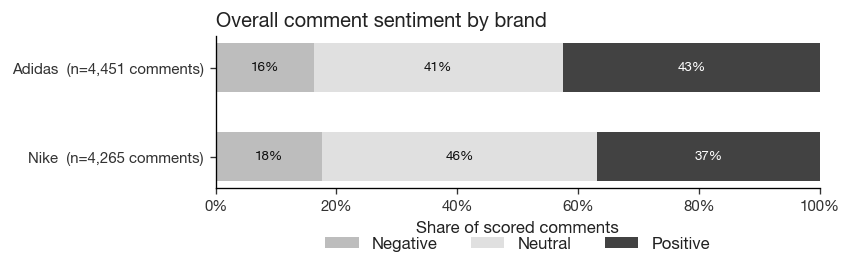

**Nike:** positive 36.8%, negative 17.6% (n=4,265 scored comments; mean=0.109, median=0.000)

**Adidas:** positive 42.6%, negative 16.2% (n=4,451 scored comments; mean=0.160, median=0.000)

In [2]:

summary = brand_perception_summary(comments)
show_fig(sentiment_stacked_bars(summary))

for _, row in summary.iterrows():
    display(Markdown(
        f"**{str(row['brand']).title()}:** "
        f"positive {100*row['share_positive']:.1f}%, "
        f"negative {100*row['share_negative']:.1f}% "
        f"(n={int(row['n_comments']):,} scored comments; "
        f"mean={row['mean_sentiment']:.3f}, median={row['median_sentiment']:.3f})"
    ))


## 2. Content context and sentiment



Do different video contexts draw different audience comment tone?



Three video-level axes (aligned with Themes 1–3):

- **Content type:** format / situation

- **Brand style:** positioning style (`lifestyle`, `performance`, …)

- **Text content cluster:** caption/embedding clusters (`content_cluster_id_clean_k12`)



Each axis shows **positive**, **negative**, and **net = pos − neg**. Comparable cells need both brands. Single-brand rows are supporting only. Gap callouts: `+9.0 Adidas` = Adidas higher by 9.0 percentage points.



**n** on these charts = scored comments joined to labeled videos.



### 2.1 Content type

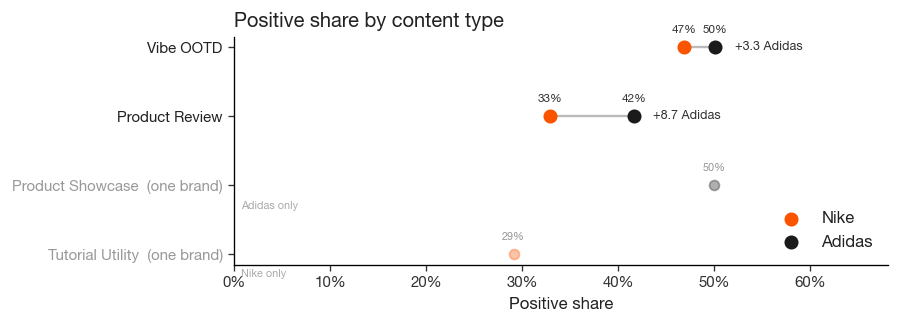

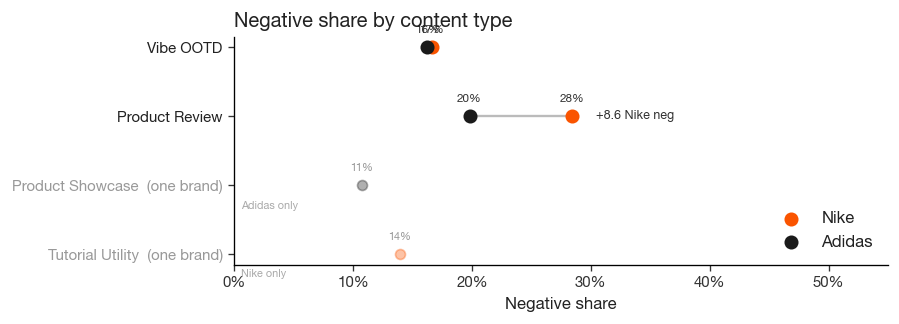

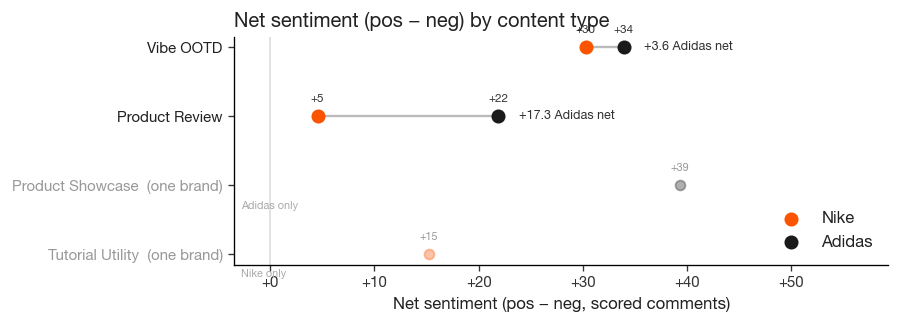

**Both brands:** Product Review, Vibe OOTD

level,brand,n,share_positive,share_negative,net
Product Review,Adidas,96,41.7%,19.8%,+21.9%
Product Review,Nike,88,33.0%,28.4%,+4.5%
Vibe OOTD,Adidas,351,50.1%,16.2%,+33.9%
Vibe OOTD,Nike,271,46.9%,16.6%,+30.3%


### 2.2 Brand style

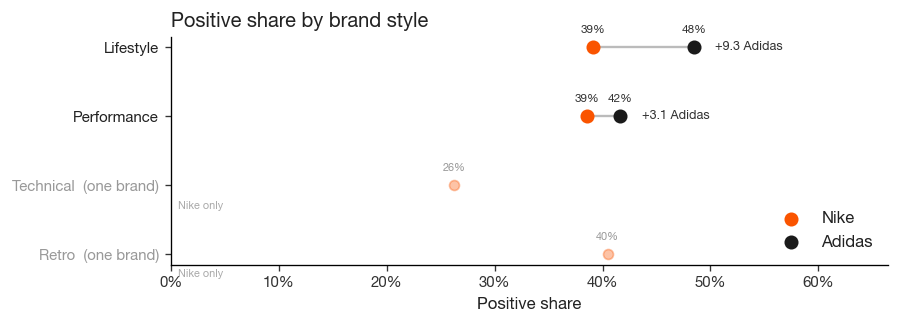

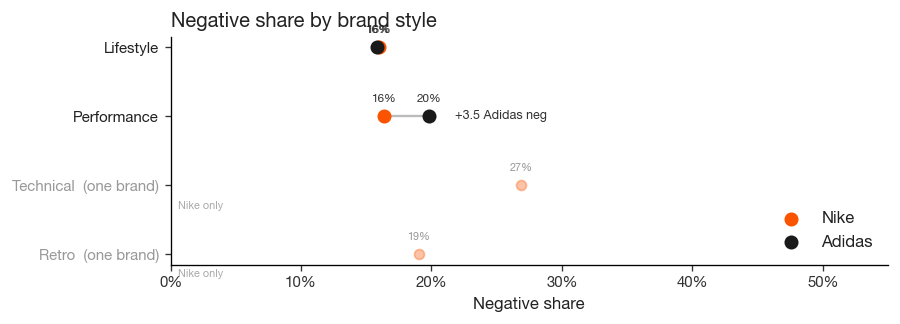

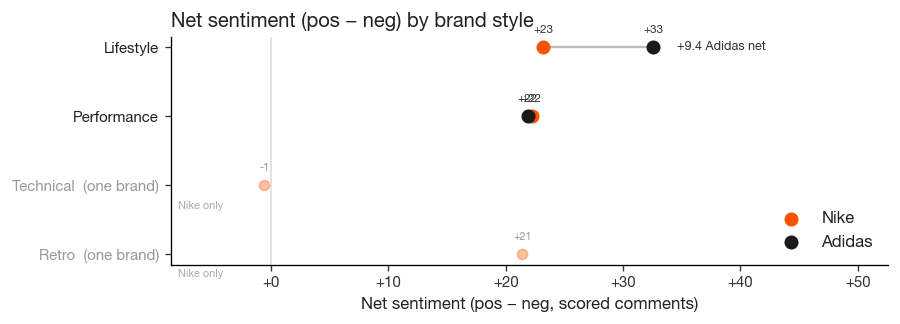

**Both brands:** Lifestyle, Performance

level,brand,n,share_positive,share_negative,net
Lifestyle,Adidas,448,48.4%,15.8%,+32.6%
Lifestyle,Nike,263,39.2%,16.0%,+23.2%
Performance,Adidas,96,41.7%,19.8%,+21.9%
Performance,Nike,153,38.6%,16.3%,+22.2%


### 2.3 Text content cluster

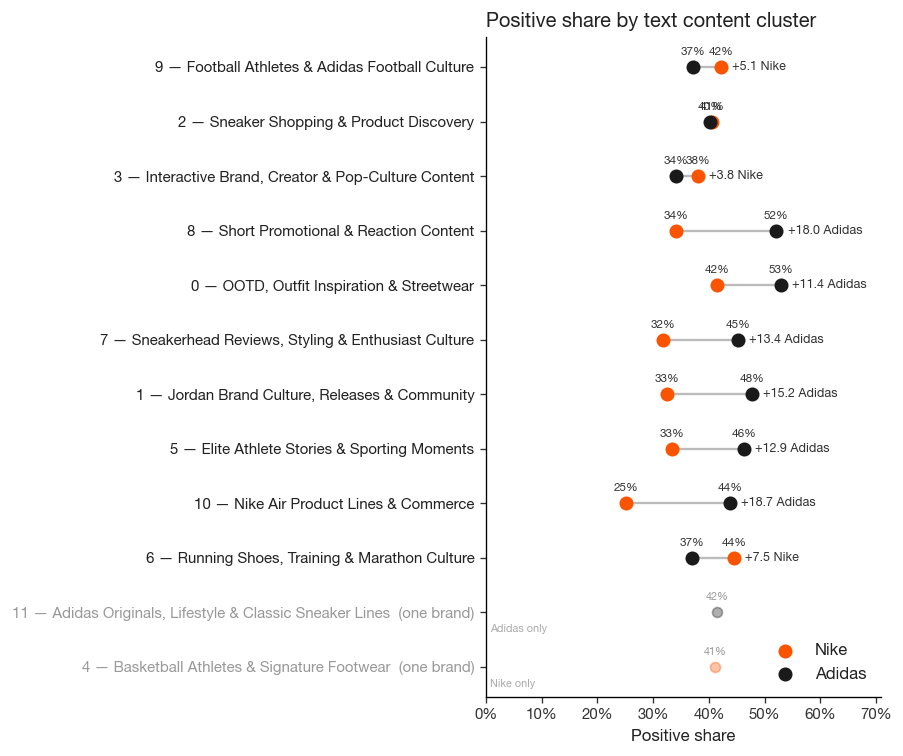

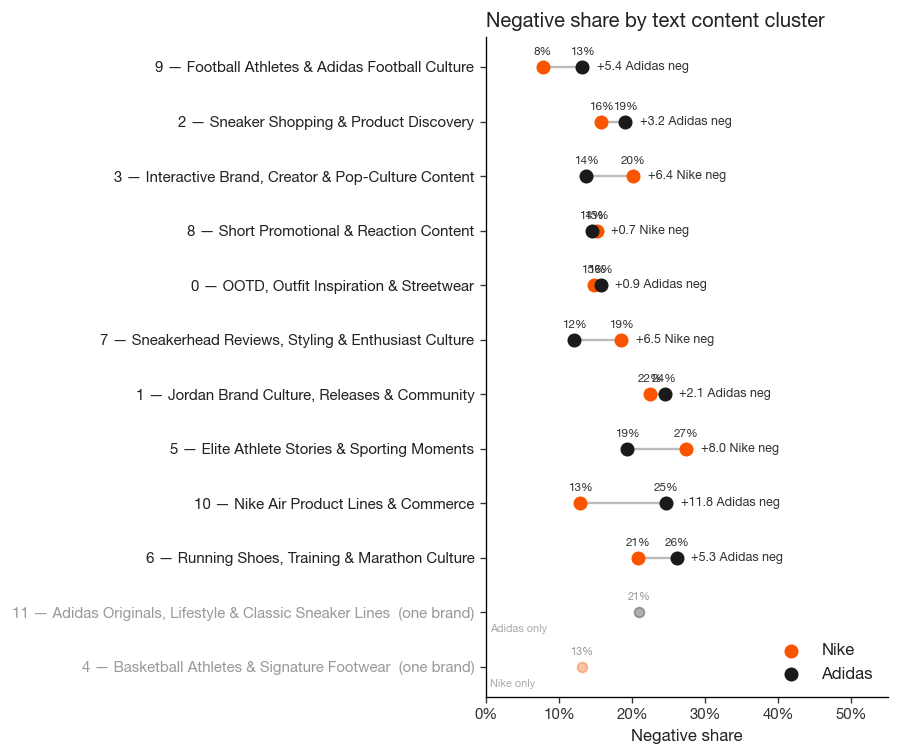

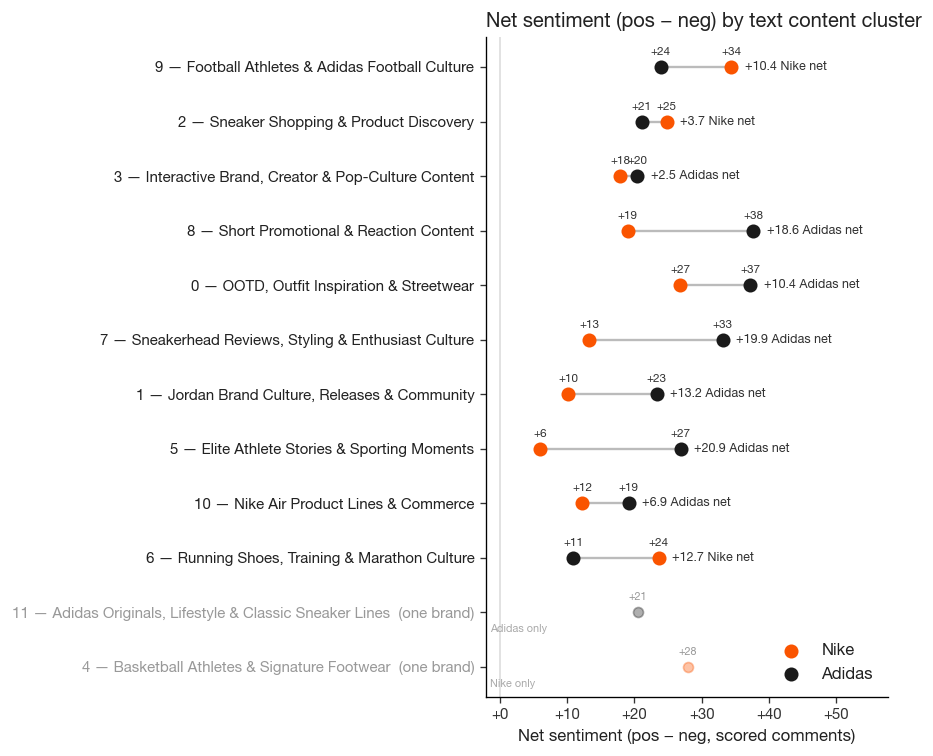

**Both brands:** 0 — OOTD, Outfit Inspiration & Streetwear, 1 — Jordan Brand Culture, Releases & Community, 2 — Sneaker Shopping & Product Discovery, 3 — Interactive Brand, Creator & Pop-Culture Content, 5 — Elite Athlete Stories & Sporting Moments, 6 — Running Shoes, Training & Marathon Culture, 7 — Sneakerhead Reviews, Styling & Enthusiast Culture, 8 — Short Promotional & Reaction Content, 9 — Football Athletes & Adidas Football Culture, 10 — Nike Air Product Lines & Commerce

level,brand,n,share_positive,share_negative,net
"0 — OOTD, Outfit Inspiration & Streetwear",Adidas,516,52.9%,15.7%,+37.2%
"0 — OOTD, Outfit Inspiration & Streetwear",Nike,508,41.5%,14.8%,+26.8%
"1 — Jordan Brand Culture, Releases & Community",Adidas,90,47.8%,24.4%,+23.3%
"1 — Jordan Brand Culture, Releases & Community",Nike,335,32.5%,22.4%,+10.1%
2 — Sneaker Shopping & Product Discovery,Adidas,777,40.2%,19.0%,+21.1%
2 — Sneaker Shopping & Product Discovery,Nike,544,40.6%,15.8%,+24.8%
"3 — Interactive Brand, Creator & Pop-Culture Content",Adidas,240,34.2%,13.8%,+20.4%
"3 — Interactive Brand, Creator & Pop-Culture Content",Nike,"1,024",38.0%,20.1%,+17.9%
5 — Elite Athlete Stories & Sporting Moments,Adidas,93,46.2%,19.4%,+26.9%
5 — Elite Athlete Stories & Sporting Moments,Nike,168,33.3%,27.4%,+6.0%


In [3]:
def _show_context_block(tab, both, *, heading, title_stem, min_count=30):

    display(Markdown(heading))

    show_fig(content_type_sentiment_dumbbell(

        tab, metric="share_positive", title=f"Positive share by {title_stem}", min_count=min_count,

    ))

    show_fig(content_type_sentiment_dumbbell(

        tab, metric="share_negative", title=f"Negative share by {title_stem}", min_count=min_count,

    ))

    show_fig(content_type_sentiment_dumbbell(

        tab, metric="net", title=f"Net sentiment (pos − neg) by {title_stem}", min_count=min_count,

    ))

    display(Markdown(

        "**Both brands:** "

        + (", ".join(humanize_label(x) for x in both) if both else "none")

    ))

    comp = tab.loc[tab["level"].isin(both)].copy() if both else tab.iloc[0:0]

    if len(comp):

        show = comp.copy()

        show["level"] = show["level"].map(humanize_label)

        show["brand"] = show["brand"].astype(str).str.title()

        show["net"] = show["share_positive"] - show["share_negative"]

        display(

            show[["level", "brand", "n", "share_positive", "share_negative", "net"]]

            .style.format({

                "n": "{:,}",

                "share_positive": "{:.1%}",

                "share_negative": "{:.1%}",

                "net": "{:+.1%}",

            })

            .hide(axis="index")

        )



# --- 2.1 Content type ---

tab_ct = content_type_sentiment(comments, videos, min_count=30)

_show_context_block(

    tab_ct, content_types_both_brands(tab_ct),

    heading="### 2.1 Content type", title_stem="content type",

)



# --- 2.2 Brand style ---

tab_bs = brand_style_sentiment(comments, videos, min_count=30)

_show_context_block(

    tab_bs, content_types_both_brands(tab_bs),

    heading="### 2.2 Brand style", title_stem="brand style",

)



# --- 2.3 Text content cluster ---

tab_cc = content_cluster_sentiment(comments, videos, min_count=30)

_show_context_block(

    tab_cc, content_types_both_brands(tab_cc),

    heading="### 2.3 Text content cluster", title_stem="text content cluster",

)



## 2b. Discovery clusters (audit)

SBERT cluster cards for inspection. Cluster membership is not used as the reporting topic label.


In [4]:

import json

aud = PATHS["feature_table"].parent / "audits"
cards_path = aud / "comment_topic_cluster_cards.jsonl"
if not cards_path.exists():
    display(Markdown("Cluster cards not found. Run `scripts/discover_comment_topics` if needed."))
else:
    cards = [json.loads(l) for l in cards_path.read_text().splitlines() if l.strip()]
    sbert = [c for c in cards if c.get("method") == "sbert_kmeans"]
    rows = [{
        "cluster_id": c["cluster_id"],
        "n": c["n"],
        "top_words": ", ".join(c.get("top_words") or [])[:80],
    } for c in sorted(sbert, key=lambda x: -x["n"])]
    display(pd.DataFrame(rows).style.hide(axis="index"))


cluster_id,n,top_words
3,1776,"photo, love, yamal, bro, ryan, want, nike, lamine, like, pedri, need, beautiful"
2,1142,"like, don, bro, did, photo, just, thought, dave, got, miss, know, ate"
9,1023,"photo, nike, need, jordan, air, best, new, pls, tech, force, quarter, air force"
1,812,"love, beautiful, cute, pretty, photo, like, good, girl, lisa, look, gorgeous, co"
6,737,"ones, black, want, need, got, photo, blue, buy, color, white, look, just"
5,681,"just, like, better, people, f1, hours, don, good, innovation, left, make, look"
0,624,"photo, new, video, nike, bro, real, ryan, like, tech, song, nike tech, meme"
4,611,"shoes, shoe, socks, pants, like, feet, just, bowling shoes, bowling, wear, laces"
8,559,"buy, size, money, price, did, just, expensive, bought, 150, like, wear, sale"
10,529,"jordan, best, basketball, lebron, football, player, ball, team, nike, better, pr"


## 3. Topic volume



Labels are **keyword/lexicon** matched per comment (`configs/comment_topics.yaml` `seed_keywords`), then bucketed into layers. Attribute keywords beat entity/product-model fallback.



**These keywords are not clusters.** Discovery clusters (SBERT/NMF) are inspection-only. The table below is a **classification lexicon** summarized from cluster inspection + business logic.



**Layers**

- **Substantive:** commercial / product conversation (main analysis)

- **Product reaction:** product-adjacent slang (fire / clean / hard / mid); not forced into Design

- **Social:** meme / tags / generic social chatter

- **Residual:** no keyword hit (unclear / untranslated / fragment)



**Substantive taxonomy:** 9 topics in config. Charts keep topics with enough comments (`min_count=20` for volume). **Brand Comparison** (n≈9) and **Quality / Performance** (n≈19) stay in the taxonomy but are omitted from plotted bars (too thin for stable shares).



Shares are within each plotted group. Residual is not forced into commercial topics.



**Topic keyword table.** Example signals from `seed_keywords` (classification lexicon, not cluster membership). Full lists: `configs/comment_topics.yaml`.

topic,example_signals
Design & Aesthetics,"color way, what colorway, what colourway, clean look, looks fire, look fire, looks good, look good"
Product Desire / Purchase Intent,"need these, need them, want these, want them, need a pair, where can i get a pair, add to cart, adding to cart"
Price & Value,"too expensive, worth it, not worth, how much, take my money, for 90, make profit, double what"
Fit & Comfort,"true to size, too small, too big, wide feet, add height, wide or, white laces, same sizes"
Athlete / Celebrity,"lamine yamal, lebron james, signature shoe, worn by, basketball player, football player, soccer player, lil nas"
Product / Model Discussion,"air force one, air force, air for one, nike tech, tech fleece, nike pro, adidas campus, adidas spezial"
Brand Comparison / Preference,"adidas better, nike better, prefer adidas, prefer nike, adidas girlie, nike girlie, team adidas, team nike"
Availability / Access,"sold out, sold out again, where to buy, where can i get, where can i buy, where can i find, where did you get, where did u get"
Quality / Performance,"falling apart, cheaply made, build quality, fell apart, shin splints, what paint, air them out, indoor soccer"
Generic Product Reaction,"these are fire, this is fire, these fire, so fire, clean af, these are clean, this is clean, so clean"


Layer sizes: **residual** 4,312 (41.4%), **substantive** 3,011 (28.9%), **social** 2,816 (27.1%), **product_reaction** 267 (2.6%)

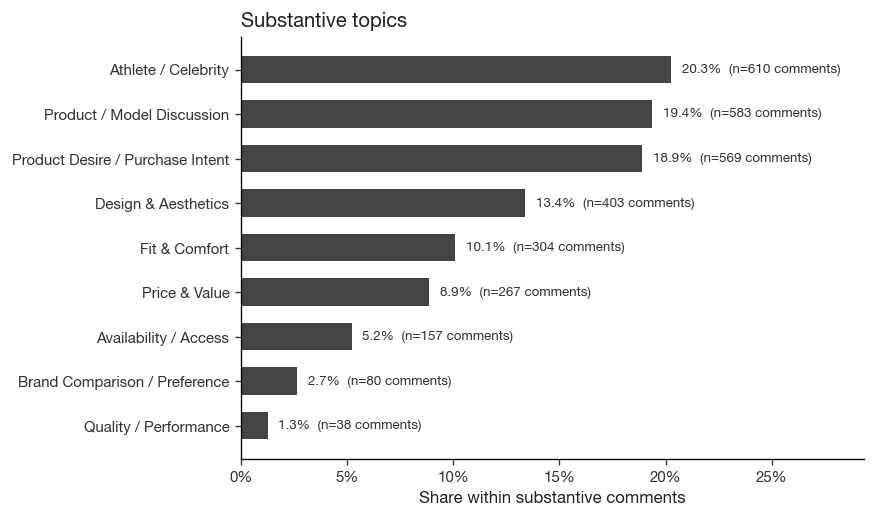

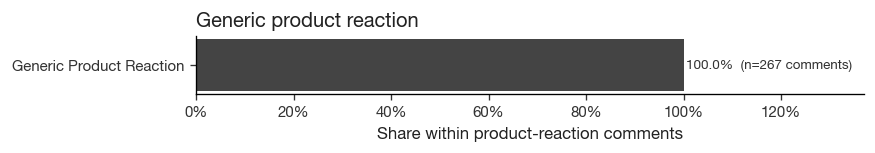

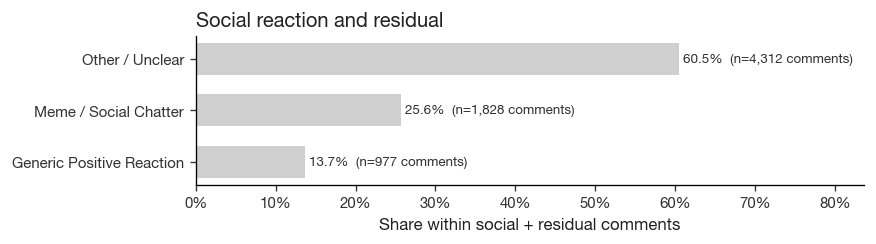

In [5]:
# Lexicon examples (not clusters)

lex = topic_lexicon_examples(layers=["substantive", "product_reaction"], max_examples=8)

display(Markdown(

    "**Topic keyword table.** Example signals from `seed_keywords` (classification lexicon, "

    "not cluster membership). Full lists: `configs/comment_topics.yaml`."

))

display(

    lex[["topic", "example_signals"]]

    .style.hide(axis="index")

)



if "comment_topic" not in comments.columns:

    display(Markdown("Missing `comment_topic`. Run: `PYTHONPATH=src python -m scripts.discover_comment_topics --classify-only`"))

    vol_sub = vol_social = None

else:

    vol_sub = topic_volume_by_brand(comments, min_count=20, layers=["substantive"], taxonomy=label_map)

    vol_pr = topic_volume_by_brand(comments, min_count=10, layers=["product_reaction"], taxonomy=label_map)

    vol_social = topic_volume_by_brand(

        comments, min_count=20, layers=["social", "residual"], taxonomy=label_map

    )



    layer_counts = comments["topic_layer"].value_counts()

    display(Markdown(

        "Layer sizes: "

        + ", ".join(

            f"**{k}** {int(v):,} ({100*v/n_all:.1f}%)"

            for k, v in layer_counts.items()

        )

    ))

    show_fig(topic_volume_hbar(

        vol_sub,

        title="Substantive topics",

        xlabel="Share within substantive comments",

    ))

    if len(vol_pr):

        show_fig(topic_volume_hbar(

            vol_pr,

            title="Generic product reaction",

            xlabel="Share within product-reaction comments",

            residual_substr=(),

        ))

    show_fig(topic_volume_hbar(

        vol_social,

        title="Social reaction and residual",

        residual_substr=("Other", "Unclear", "Generic", "Meme", "Social"),

        xlabel="Share within social + residual comments",

    ))



## 4. Topic × brand sentiment

Positive, negative, and **net = positive − negative** by substantive topic (Nike vs Adidas).
Denominator: scored comments (**n = comments**).

Dumbbells require both brands with ≥25 scored comments in the topic. **Brand Comparison** and **Quality / Performance** are in the 9-topic taxonomy but fall below that floor here (n≈8–19), so they do not appear on the charts.


Scored comments: **8,716**; substantive scored rows: **2,772**.

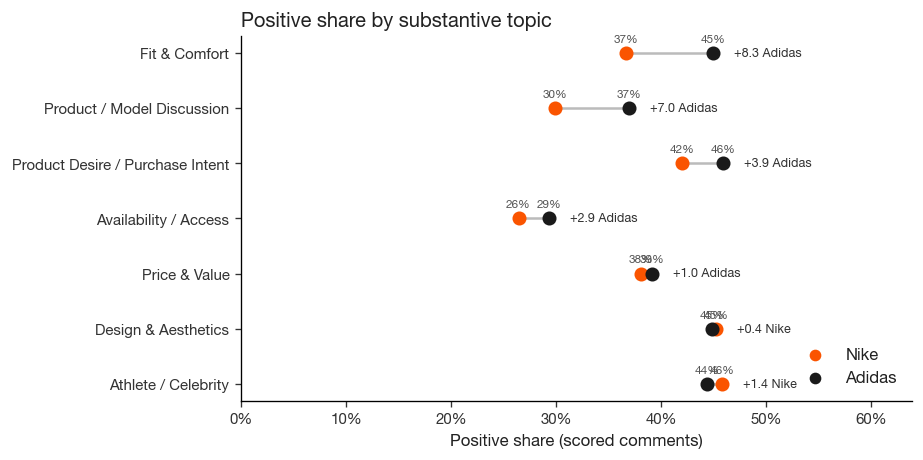

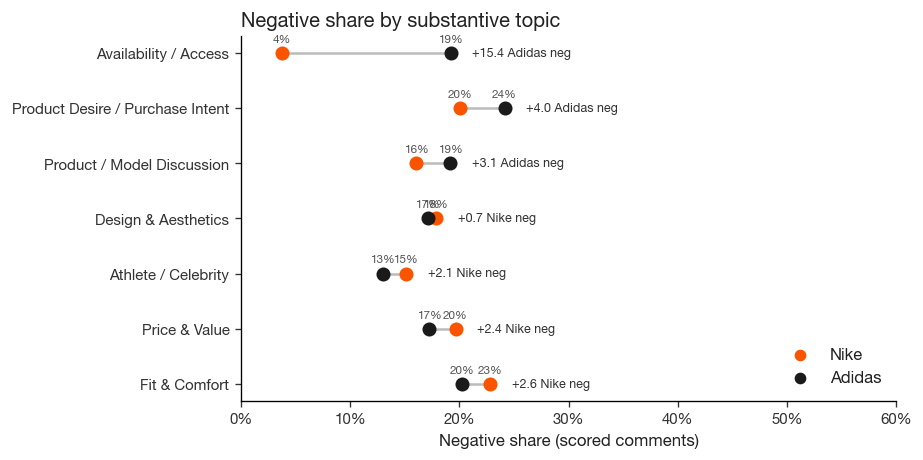

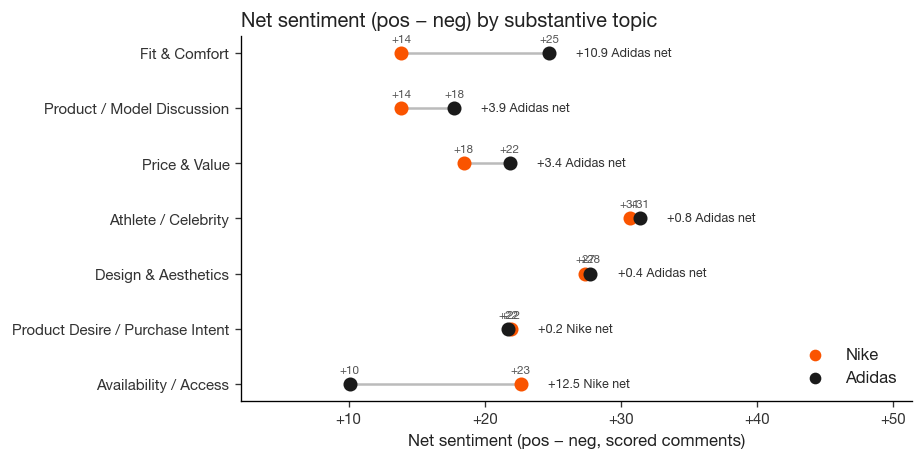

Support table (**n = comments**): **gap** = Adidas−Nike positive; **neg_gap** = Adidas−Nike negative; **net** = positive−negative.

topic,n,nike_n,adidas_n,nike_share_positive,adidas_share_positive,gap,nike_share_negative,adidas_share_negative,neg_gap,nike_net,adidas_net,net_gap
Fit & Comfort,299,101,198,36.6%,44.9%,+8.3%,22.8%,20.2%,-2.6%,+13.9%,+24.7%,+10.9%
Product / Model Discussion,495,281,214,29.9%,36.9%,+7.0%,16.0%,19.2%,+3.1%,+13.9%,+17.8%,+3.9%
Product Desire / Purchase Intent,509,219,290,42.0%,45.9%,+3.9%,20.1%,24.1%,+4.0%,+21.9%,+21.7%,-0.2%
Availability / Access,152,53,99,26.4%,29.3%,+2.9%,3.8%,19.2%,+15.4%,+22.6%,+10.1%,-12.5%
Price & Value,255,168,87,38.1%,39.1%,+1.0%,19.6%,17.2%,-2.4%,+18.5%,+21.8%,+3.4%
Design & Aesthetics,391,157,234,45.2%,44.9%,-0.4%,17.8%,17.1%,-0.7%,+27.4%,+27.8%,+0.4%
Athlete / Celebrity,559,212,347,45.8%,44.4%,-1.4%,15.1%,13.0%,-2.1%,+30.7%,+31.4%,+0.8%
Quality / Performance,36,19,17,36.8%,29.4%,-7.4%,21.1%,17.6%,-3.4%,+15.8%,+11.8%,-4.0%
Brand Comparison / Preference,76,15,61,66.7%,52.5%,-14.2%,13.3%,14.8%,+1.4%,+53.3%,+37.7%,-15.6%


In [6]:
if "comment_topic" not in comments.columns:

    display(Markdown("Skipped: classify topics first."))

    gap = gap_neg = gap_net = None

else:

    topic_sent = topic_sentiment_by_brand(

        comments, min_count=25, layers=["substantive"], taxonomy=label_map

    )

    gap = topic_sentiment_gap(topic_sent, metric="share_positive")

    gap_neg = topic_sentiment_gap(topic_sent, metric="share_negative")

    gap_net = topic_sentiment_gap(topic_sent, metric="net")

    display(Markdown(

        f"Scored comments: **{topic_sent.attrs.get('n_scored', n_scored):,}**; "

        f"substantive scored rows: **{topic_sent.attrs.get('n_topic_scored_rows', 0):,}**."

    ))

    show_fig(topic_sentiment_gap_dumbbell(

        gap,

        title="Positive share by substantive topic",

        metric="share_positive",

        min_brand_n=25,

    ))

    show_fig(topic_sentiment_gap_dumbbell(

        gap_neg,

        title="Negative share by substantive topic",

        metric="share_negative",

        min_brand_n=25,

    ))

    show_fig(topic_sentiment_gap_dumbbell(

        gap_net,

        title="Net sentiment (pos − neg) by substantive topic",

        metric="net",

        min_brand_n=25,

    ))



    show = gap.copy()

    show = show.merge(

        gap_neg.rename(columns={"gap": "neg_gap"})[["topic", "neg_gap"]],

        on="topic",

        how="left",

    )

    fmt = {

        "n": "{:,}", "nike_n": "{:,}", "adidas_n": "{:,}",

        "nike_share_positive": "{:.1%}", "adidas_share_positive": "{:.1%}",

        "gap": "{:+.1%}",

        "nike_share_negative": "{:.1%}", "adidas_share_negative": "{:.1%}",

        "neg_gap": "{:+.1%}",

        "nike_net": "{:+.1%}", "adidas_net": "{:+.1%}", "net_gap": "{:+.1%}",

    }

    cols = [c for c in [

        "topic", "n", "nike_n", "adidas_n",

        "nike_share_positive", "adidas_share_positive", "gap",

        "nike_share_negative", "adidas_share_negative", "neg_gap",

        "nike_net", "adidas_net", "net_gap",

    ] if c in show.columns]

    display(Markdown(

        "Support table (**n = comments**): **gap** = Adidas−Nike positive; "

        "**neg_gap** = Adidas−Nike negative; **net** = positive−negative."

    ))

    display(show[cols].style.format(fmt).hide(axis="index"))



## 5. Summary

*Sample: 105 videos, ~10.4k comments; ~84% scored. Comment-level taxonomy. Descriptive only. Topic labels provisional pending further residual recovery.*

**Overall.** Sentiment distributions are similar. Adidas positive share is higher (~43% vs ~37%); negative shares are close (~16–18%).

**Content context.** `content_type` comparable cells: Product Review and Vibe/OOTD. Review is cooler for Nike (positive ~33% vs ~42%; negative ~28% vs ~20%); OOTD is favorable for both. `brand_styles` comparable cells: Lifestyle and Performance. Lifestyle is warmer for Adidas (positive ~48% vs ~39%); Performance is closer. Nike-only Technical is a cool supporting profile (positive ~26%, negative ~27%). Single-brand rows are not cross-brand wins.

**Topics (provisional).** Four layers (substantive / product_reaction / social / residual). After human coding of 400 residual comments and a lexicon expand+reclassify pass, layer mix is about residual **41.4%**, social **27.1%**, substantive **28.9%**, product_reaction **2.6%**. Residual remains high at 41.4%. Coding showed ~53% of that residual sample was recoverable commercial or product-reaction content and only ~8.5% was true unclear; lexicon recovery on that sample is partial (~45% of recoverable rows), so do not treat 53% as an automatic new layer target. Topic commercial narrative stays unlocked until further recovery or a second coding pass.

**Sentiment structure (scored substantive; read positive, negative, and net).** Adidas is often warmer on Product/Model and Design. Purchase Desire and Fit can look Adidas-positive on positive share while remaining more polarized (higher negative share). Net sentiment may reverse or shrink the gap. Price/Value and Athlete should be read with *n* and net sentiment, not as premium-acceptance or marketing-ROI claims.

**Next.** Iterate lexicon from remaining misses in `taxonomy_residual_sample_400_coded.csv`; keep evidence trail in `audits/taxonomy_audit_notes.md`. Fold locked bullets into `05_summary.ipynb` when signed off.
